# 01 - EDA

This notebook performs a comprehensive exploratory data analysis on the pricing dataset used to train the machine learning models in the project

In [23]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL = "https://github.com/Mudibo/AgriSence.git" 

if IN_COLAB:
    REPO_DIR = Path("/content/AgriSence")
    if not REPO_DIR.exists():
        !git clone {REPO_URL} {REPO_DIR}
    project_root = REPO_DIR / "model"
else:
    project_root = Path.cwd().resolve().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Local imports for project modules
from config.constants import CROPS, MARKETS

sns.set_theme(style="whitegrid")


<h3>1. Data Loading</h3>

In [24]:
WFP_URL = (
    "https://data.humdata.org/dataset/wfp-food-prices-for-kenya/resource/"
    "517ee1bf-2437-4f8c-aa1b-cb9925b9d437/download/wfp_food_prices_ken.csv"
)

raw_df = pd.read_csv(WFP_URL)

# HDX exports ship a units/type row directly under the header
if raw_df.iloc[0].astype(str).str.match(r"^#").any():
    raw_df = raw_df.iloc[1:].reset_index(drop=True)

print(raw_df.shape)


(27464, 16)


<h3> 2. Dataset Inspection</h3>

In [25]:
raw_df.shape

(27464, 16)

In [26]:
raw_df.tail()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
27459,2026-08-15,Rift Valley,Turkana,Mogadishu (Kakuma),3245,3.72,34.85,milk and dairy,Milk (UHT),794,500 ML,aggregate,Retail,KES,75.00,0.58
27460,2026-08-15,Rift Valley,Turkana,Mogadishu (Kakuma),3245,3.72,34.85,miscellaneous food,Salt,185,200 G,aggregate,Retail,KES,15.00,0.12
27461,2026-08-15,Rift Valley,Turkana,Mogadishu (Kakuma),3245,3.72,34.85,miscellaneous food,Sugar,97,KG,aggregate,Retail,KES,163.33,1.26
27462,2026-08-15,Rift Valley,Turkana,Mogadishu (Kakuma),3245,3.72,34.85,oil and fats,Oil (vegetable),96,L,aggregate,Retail,KES,300.00,2.32
27463,2026-08-15,Rift Valley,Turkana,Mogadishu (Kakuma),3245,3.72,34.85,vegetables and fruits,Bananas,254,Unit,aggregate,Retail,KES,20.00,0.15


In [27]:
raw_df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,16.13,0.22
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47
3,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,3246.00,45.15
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24


In [28]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27464 entries, 0 to 27463
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          27464 non-null  object 
 1   admin1        27396 non-null  object 
 2   admin2        27396 non-null  object 
 3   market        27464 non-null  object 
 4   market_id     27464 non-null  int64  
 5   latitude      27396 non-null  float64
 6   longitude     27396 non-null  float64
 7   category      27464 non-null  object 
 8   commodity     27464 non-null  object 
 9   commodity_id  27464 non-null  int64  
 10  unit          27464 non-null  object 
 11  priceflag     27464 non-null  object 
 12  pricetype     27464 non-null  object 
 13  currency      27464 non-null  object 
 14  price         27464 non-null  float64
 15  usdprice      27464 non-null  float64
dtypes: float64(4), int64(2), object(10)
memory usage: 3.4+ MB


In [29]:
raw_df.dtypes

,0
date,object
admin1,object
admin2,object
market,object
market_id,int64
latitude,float64
longitude,float64
category,object
commodity,object
commodity_id,int64


In [30]:
raw_df["market"].nunique()

226

In [31]:
raw_df["market"].unique()

array(['Mombasa', 'Kitui', 'Marsabit', 'Nairobi', 'Mandera', 'Kisumu',
       'Lodwar (Turkana)', 'Eldoret town (Uasin Gishu)', 'Nakuru',
       'Hola (Tana River)', 'Kilifi', 'Garissa', 'Marigat (Baringo)',
       'Kajiado', 'Karatina (Nyeri)', 'Vanga (Kwale)',
       'Kitui town (Kitui)', 'Makueni', 'Wote town (Makueni)',
       'Kitengela (Kajiado)', 'Garissa town (Garissa)',
       'Takaba (Mandera)', 'Marigat town (Baringo)',
       'Illbissil Food Market (Kajiado)', 'Wakulima (Nakuru)',
       'Lomut (West Pokot)', 'Kongowea (Mombasa)',
       'Tala Centre Market (Machakos)', 'Kangemi (Nairobi)',
       'Kibuye (Kisumu)', 'Makutano (West Pokot)',
       'Kathonzweni (Makueni)', 'Kaanwa (Tharaka Nithi)',
       'Wakulima (Nairobi)', 'Shauri Yako', 'Bangale', 'Boka', 'Bura',
       'Charidende', 'Garsen', 'Hola town', 'Makere', 'Saka Town',
       'Tarasaa', 'Wayu', 'Benane', 'Biliqo', 'Boji', 'Bulesa Bulesa',
       'Garbatulla', 'Iresaboru Centre', 'Kipsing CENTER', 'Malka GALLA'

In [32]:
raw_df["commodity"].nunique()

51

In [33]:
raw_df["commodity"].unique()

array(['Maize', 'Maize (white)', 'Beans', 'Beans (dry)',
       'Potatoes (Irish)', 'Sorghum', 'Bread', 'Milk (cow, pasteurized)',
       'Oil (vegetable)', 'Fuel (diesel)', 'Fuel (kerosene)',
       'Fuel (petrol-gasoline)', 'Rice', 'Wheat flour', 'Meat (beef)',
       'Meat (goat)', 'Sugar', 'Cooking fat', 'Bananas', 'Kale',
       'Onions (red)', 'Tomatoes', 'Beans (kidney)', 'Beans (rosecoco)',
       'Beans (yellow)', 'Cabbage', 'Onions (dry)', 'Spinach',
       'Potatoes (Irish, white)', 'Rice (aromatic)', 'Sorghum (red)',
       'Beans (dolichos)', 'Cowpeas', 'Cowpea leaves',
       'Maize (white, dry)', 'Beans (mung)', 'Millet (finger)',
       'Potatoes (Irish, red)', 'Rice (imported, Pakistan)',
       'Fish (omena, dry)', 'Sorghum (white)', 'Maize flour (white)',
       'Salt', 'Oil (vegetable, fortified)', 'Cowpeas (dry)',
       'Pigeon peas (dry)', 'Maize flour', 'Milk (UHT)', 'Meat (camel)',
       'Milk (camel, fresh)', 'Milk (cow, fresh)'], dtype=object)

In [34]:

raw_df["unit"].nunique()

13

In [35]:

raw_df["unit"].unique()

array(['KG', '90 KG', '50 KG', '400 G', '500 ML', 'L', 'Unit', 'Bunch',
       '126 KG', '13 KG', '64 KG', '200 G', 'Head'], dtype=object)

In [36]:

raw_df["currency"].nunique()

1

In [37]:

raw_df["currency"].unique()

array(['KES'], dtype=object)

<h3>3. Data Quality Checks</h3>

In [38]:
#Missing values check
missing = raw_df.isnull().sum().sort_values(ascending=False)
missing

,0
admin1,68
admin2,68
longitude,68
latitude,68
market,0
date,0
market_id,0
category,0
commodity,0
commodity_id,0


In [39]:
# Percentage Calculation
missing_percentage = (raw_df.isnull().sum() / len(raw_df) * 100).sort_values(ascending=False)
missing_percentage

,0
admin1,0.247597
admin2,0.247597
longitude,0.247597
latitude,0.247597
market,0.000000
date,0.000000
market_id,0.000000
category,0.000000
commodity,0.000000
commodity_id,0.000000


In [40]:
# Investigating missingness by market
raw_df.groupby("market")["price"].apply(lambda x: x.isna().mean())

,price
market,
Adele Center,0.0
Alango Arba,0.0
Alemsekon,0.0
Alinjugur,0.0
Alungu,0.0
...,...
Wamba,0.0
Warankara,0.0
Wargadud,0.0


In [41]:
raw_df.groupby("commodity")["price"].apply(lambda x: x.isna().mean())

,price
commodity,
Bananas,0.0
Beans,0.0
Beans (dolichos),0.0
Beans (dry),0.0
Beans (kidney),0.0
Beans (mung),0.0
Beans (rosecoco),0.0
Beans (yellow),0.0
Bread,0.0


<h3>4. Duplicate Observations</h3>

In [42]:
raw_df.duplicated().sum()

np.int64(0)

In [43]:
df = raw_df.copy()

<h3>5. Date and temporal Coverage</h3>

In [44]:
#Converting date field to datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [45]:
df['date'].min()

Timestamp('2006-01-15 00:00:00')

In [46]:
df['date'].max()

Timestamp('2026-08-15 00:00:00')

<h3>6. Market Coverage</h3>

In [47]:
df['market'].value_counts().head(20)

,count
market,
Nairobi,1716
Eldoret town (Uasin Gishu),1352
Kisumu,953
IFO (Daadab),796
Kakuma 3,788
Hagadera (Daadab),762
Kakuma 4,705
Dagahaley (Daadab),678
Kalobeyei (Village 1),673


In [48]:
df[df['market'] == 'Kisumu'].sort_values(by='date').tail()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
5989,2019-10-15,Nyanza,Kisumu,Kisumu,186,-0.1,34.75,cereals and tubers,Potatoes (Irish),148,50 KG,actual,Wholesale,KES,2400.00,23.15
5990,2019-10-15,Nyanza,Kisumu,Kisumu,186,-0.1,34.75,cereals and tubers,Sorghum,65,90 KG,actual,Wholesale,KES,4000.00,38.59
5991,2019-10-15,Nyanza,Kisumu,Kisumu,186,-0.1,34.75,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,9200.00,88.76
6127,2020-02-15,Nyanza,Kisumu,Kisumu,186,-0.1,34.75,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,48.02,0.48
8592,2022-02-15,Nyanza,Kisumu,Kisumu,186,-0.1,34.75,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,35.59,0.31


In [49]:
market_counts = df['market'].value_counts()
market_counts

,count
market,
Nairobi,1716
Eldoret town (Uasin Gishu),1352
Kisumu,953
IFO (Daadab),796
Kakuma 3,788
...,...
Simale,6
Buna,6
Lokipoto,6


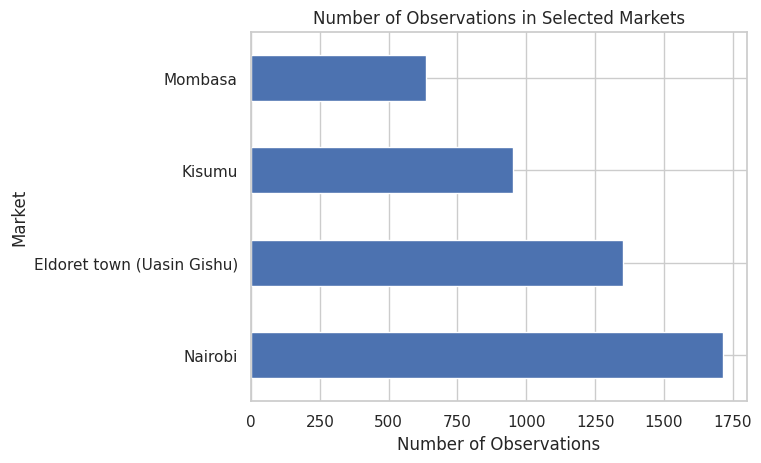

In [50]:
#Horizontal bar chart to visualize the number of observations in the Nairobi, Eldoret, Kisumu and Mombasa
market_counts[['Nairobi', 'Eldoret town (Uasin Gishu)', 'Kisumu', 'Mombasa']].plot(kind='barh')
plt.xlabel('Number of Observations')
plt.ylabel('Market')
plt.title('Number of Observations in Selected Markets')
plt.show()

<h3>7. Commodity Coverage</h3>

In [51]:
commodity_counts = df['commodity'].value_counts()
commodity_counts

,count
commodity,
Beans (dry),1797
Maize (white),1713
Maize,1517
Wheat flour,1406
Beans,1383
Sugar,1357
Salt,1323
Potatoes (Irish),1281
Sorghum,1038


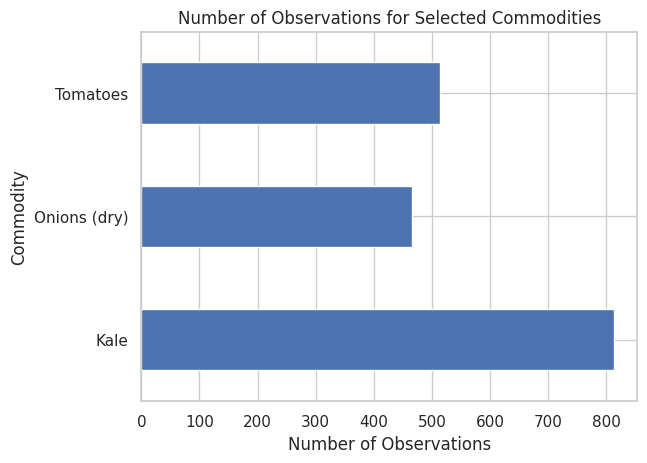

In [52]:
#Visualizing the number of observations for Kale, Onions (dry), Tomatoes
commodity_counts[['Kale', 'Onions (dry)', 'Tomatoes']].plot(kind='barh')
plt.xlabel('Number of Observations')
plt.ylabel('Commodity')
plt.title('Number of Observations for Selected Commodities')
plt.show()

<h3>8. Crop x Market Coverage</h3>

In [53]:
# Create a market crop matrix for Tomatoes, Onions (dry), Kale with Nairobi, Mombasa, Kisumu, Eldoret (Uasin Gishu)
market_crop_matrix = df.pivot_table(index='market', columns='commodity', aggfunc='size', fill_value=0)
market_crop_matrix = market_crop_matrix.loc[['Nairobi', 'Mombasa', 'Kisumu', 'Eldoret town (Uasin Gishu)'], ['Tomatoes', 'Onions (dry)', 'Kale']]
market_crop_matrix

commodity,Tomatoes,Onions (dry),Kale
market,,,
Nairobi,1,0,1
Mombasa,0,0,0
Kisumu,0,0,0
Eldoret town (Uasin Gishu),41,42,39


In [54]:
# Rank market-crop combinations by observation count to find the best candidates for model training
market_crop_counts = (
    market_crop_matrix
    .stack()
    .rename("observations")
    .reset_index()
    .sort_values("observations", ascending=False)
    .reset_index(drop=True)
)
market_crop_counts

,market,commodity,observations
0,Eldoret town (Uasin Gishu),Onions (dry),42
1,Eldoret town (Uasin Gishu),Tomatoes,41
2,Eldoret town (Uasin Gishu),Kale,39
3,Nairobi,Tomatoes,1
4,Nairobi,Kale,1
5,Nairobi,Onions (dry),0
6,Mombasa,Tomatoes,0
7,Mombasa,Onions (dry),0
8,Kisumu,Onions (dry),0
9,Kisumu,Tomatoes,0


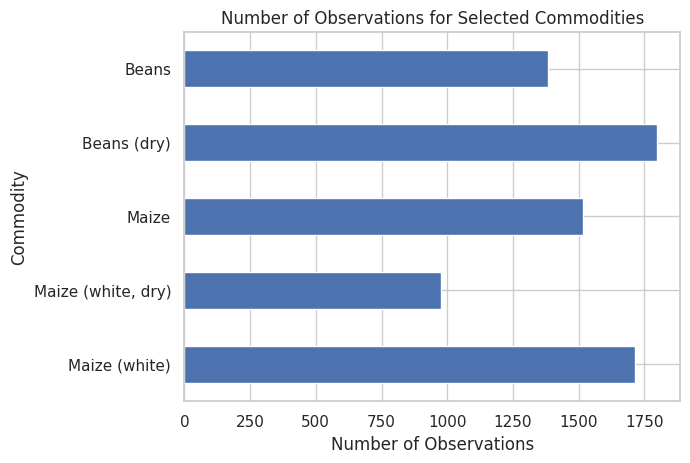

In [55]:
#Visualizing the number of observations for Maize (white), Maize (white, dry), Maize, Beans (dry), Beans
commodity_counts[['Maize (white)', 'Maize (white, dry)','Maize', 'Beans (dry)','Beans']].plot(kind='barh')
plt.xlabel('Number of Observations')
plt.ylabel('Commodity')
plt.title('Number of Observations for Selected Commodities')
plt.show()

In [56]:
# Create a market crop matrix for Maize (white), Beans with Nairobi, Mombasa, Kisumu, Eldoret (Uasin Gishu)
market_crop_matrix_2 = df.pivot_table(index='market', columns='commodity', aggfunc='size', fill_value=0)
market_crop_matrix_2 = market_crop_matrix_2.loc[['Nairobi', 'Mombasa', 'Kisumu', 'Eldoret town (Uasin Gishu)'], ['Maize (white)', 'Maize (white, dry)','Maize', 'Beans (dry)','Beans']]
market_crop_matrix_2

commodity,Maize (white),"Maize (white, dry)",Maize,Beans (dry),Beans
market,,,,,
Nairobi,170,0,190,171,144
Mombasa,167,0,154,167,143
Kisumu,164,0,144,163,160
Eldoret town (Uasin Gishu),170,42,188,146,156


<h3>9. Price distribution </h3>

In [57]:
df['price'].describe()

,price
count,27464.000000
mean,1296.420081
std,2560.466071
min,5.000000
25%,70.000000
50%,130.000000
75%,1000.000000
max,19800.000000


<h3>10. Price distribution by Crop</h3>

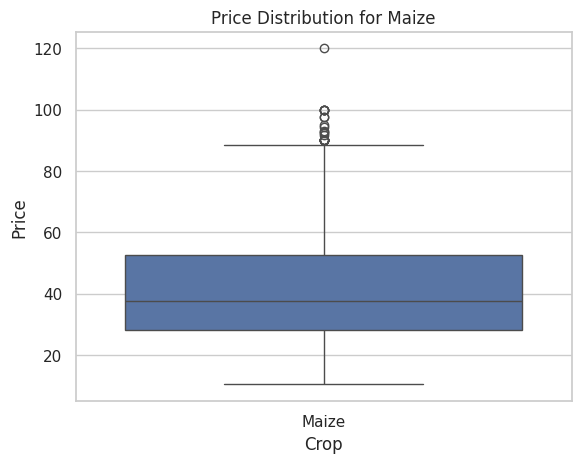

In [58]:
# Boxplot of price by crop for Maize
sns.boxplot(x='commodity', y='price', data=df[df['commodity'] == 'Maize'])
plt.title('Price Distribution for Maize')
plt.xlabel('Crop')
plt.ylabel('Price')
plt.show()

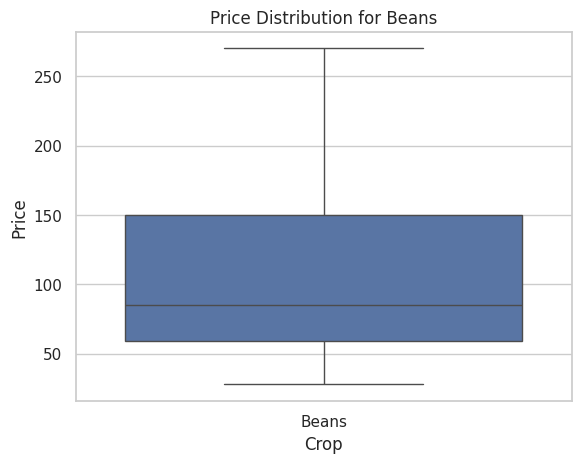

In [59]:
# Boxplot of price by crop for Beans
sns.boxplot(x='commodity', y='price', data=df[df['commodity'] == 'Beans'])
plt.title('Price Distribution for Beans')
plt.xlabel('Crop')
plt.ylabel('Price')
plt.show()

<h3>11. Price distribution by Market</h3>

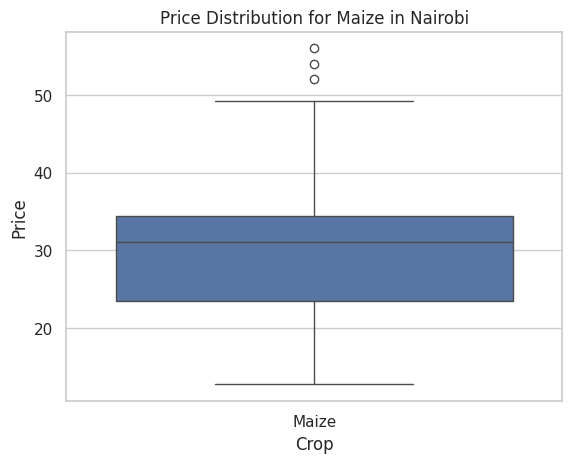

In [60]:
# Boxplot of price by crop for Maize in Nairobi
sns.boxplot(x='commodity', y='price', data=df[(df['commodity'] == 'Maize') & (df['market'] == 'Nairobi')])
plt.title('Price Distribution for Maize in Nairobi')
plt.xlabel('Crop')
plt.ylabel('Price')
plt.show()

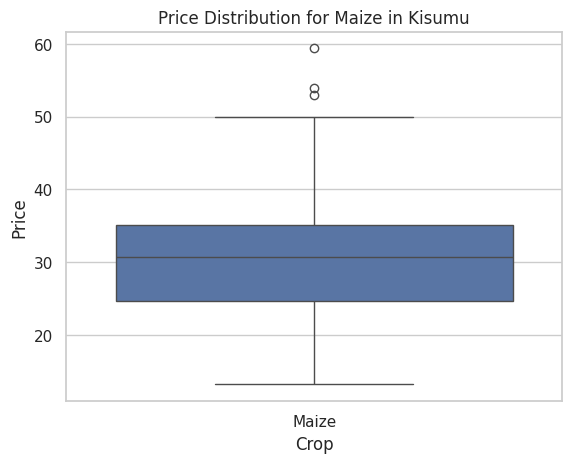

In [61]:
# Boxplot of price by crop for Maize in Kisumu
sns.boxplot(x='commodity', y='price', data=df[(df['commodity'] == 'Maize') & (df['market'] == 'Kisumu')])
plt.title('Price Distribution for Maize in Kisumu')
plt.xlabel('Crop')
plt.ylabel('Price')
plt.show()

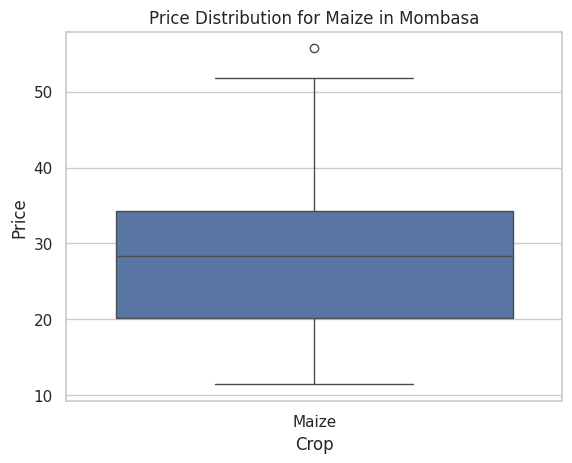

In [62]:
# Boxplot of price by crop for Maize in Mombasa
sns.boxplot(x='commodity', y='price', data=df[(df['commodity'] == 'Maize') & (df['market'] == 'Mombasa')])
plt.title('Price Distribution for Maize in Mombasa')
plt.xlabel('Crop')
plt.ylabel('Price')
plt.show()

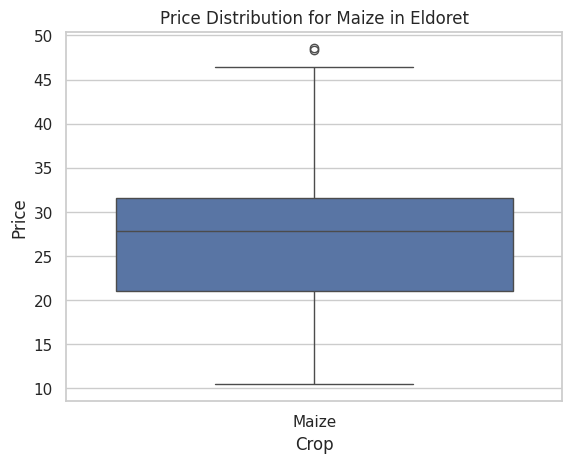

In [63]:
# Boxplot of price by crop for Maize in Eldoret (Uasin Gishu)
sns.boxplot(x='commodity', y='price', data=df[(df['commodity'] == 'Maize') & (df['market'] == 'Eldoret town (Uasin Gishu)')])
plt.title('Price Distribution for Maize in Eldoret')
plt.xlabel('Crop')
plt.ylabel('Price')
plt.show()

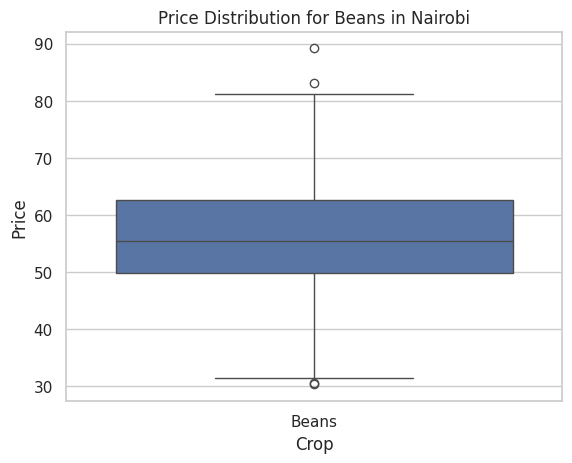

In [64]:
# Boxplot of price by crop for Beans in Nairobi
sns.boxplot(x='commodity', y='price', data=df[(df['commodity'] == 'Beans') & (df['market'] == 'Nairobi')])
plt.title('Price Distribution for Beans in Nairobi')
plt.xlabel('Crop')
plt.ylabel('Price')
plt.show()

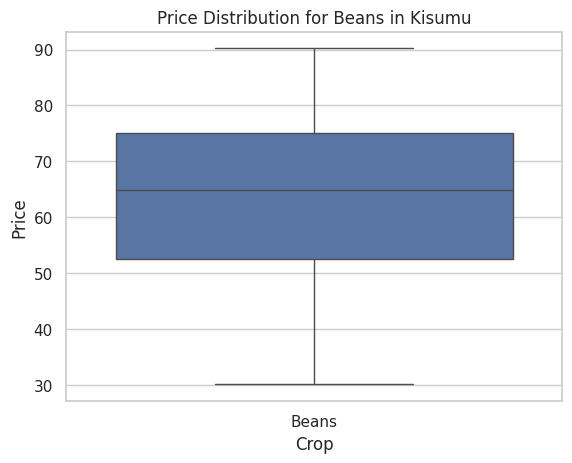

In [65]:
# Boxplot of price by crop for Beans in Kisumu
sns.boxplot(x='commodity', y='price', data=df[(df['commodity'] == 'Beans') & (df['market'] == 'Kisumu')])
plt.title('Price Distribution for Beans in Kisumu')
plt.xlabel('Crop')
plt.ylabel('Price')
plt.show()

<h3>12. Time-series Analysis</h3>

In [66]:
monthly = (
    df.groupby([
        pd.Grouper(key="date", freq="MS"),
        "market",
        "commodity"
    ])["price"]
    .mean()
    .reset_index()
)

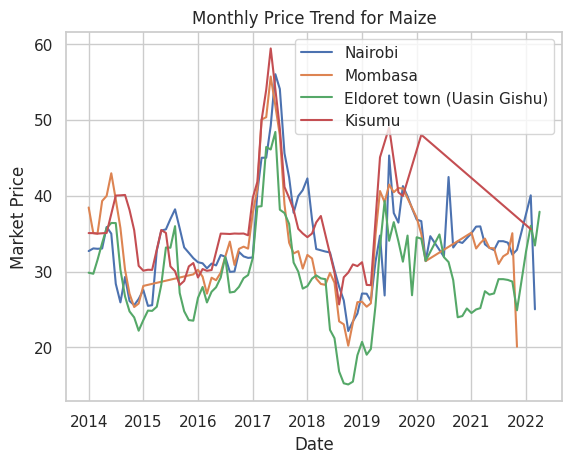

In [67]:
# Visualization to view monthly price trend for Maize in Nairobi, Mombasa, Eldoret town (Uasin Gishu), Kisumu between 2014 and 2026

markets_of_interest = ["Nairobi", "Mombasa", "Eldoret town (Uasin Gishu)", "Kisumu"]

maize_monthly = monthly[(monthly["commodity"] == "Maize") & (monthly["date"].dt.year >= 2014) & (monthly["date"].dt.year <= 2026)]
for market in markets_of_interest:
    market_data = maize_monthly[maize_monthly["market"] == market]
    plt.plot(market_data["date"], market_data["price"], label=market)
plt.xlabel("Date")
plt.ylabel("Market Price")
plt.title("Monthly Price Trend for Maize")
plt.legend()
plt.show()

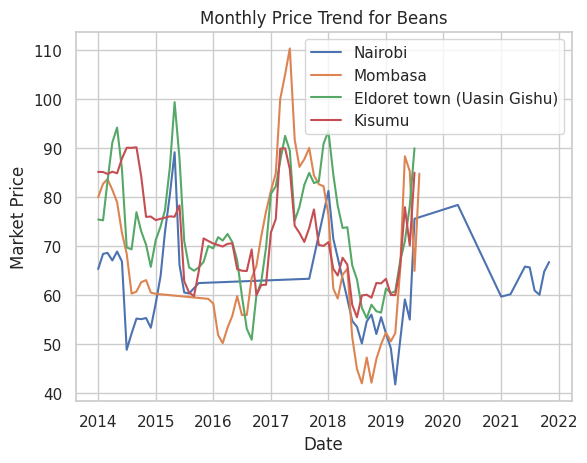

In [69]:
# Visualization to view monthly price trend for Beans in Nairobi, Mombasa, Eldoret town (Uasin Gishu), Kisumu between 2014 and 2026

markets_of_interest = ["Nairobi", "Mombasa", "Eldoret town (Uasin Gishu)", "Kisumu"]

beans_monthly = monthly[(monthly["commodity"] == "Beans") & (monthly["date"].dt.year >= 2014) & (monthly["date"].dt.year <= 2026)]
for market in markets_of_interest:
    market_data = beans_monthly[beans_monthly["market"] == market]
    plt.plot(market_data["date"], market_data["price"], label=market)
plt.xlabel("Date")
plt.ylabel("Market Price")
plt.title("Monthly Price Trend for Beans")
plt.legend()
plt.show()

<h3>13. Seasonal Analysis</h3>

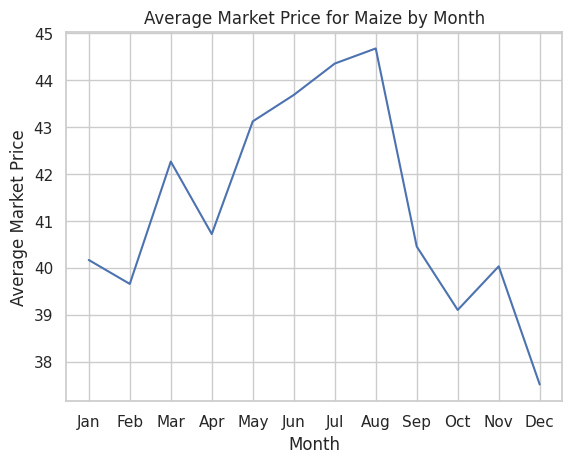

In [ ]:
# Visualization to view seasonal price profile by month for Maize
monthly["month"] = monthly["date"].dt.month
maize_seasonal = monthly[monthly["commodity"] == "Maize"]
seasonal_profile = maize_seasonal.groupby("month")["price"].mean()
plt.plot(seasonal_profile.index, seasonal_profile.values)
plt.xticks(ticks=range(1, 13), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.xlabel("Month")
plt.ylabel("Average Market Price")
plt.title("Average Market Price for Maize per Month")
plt.show()


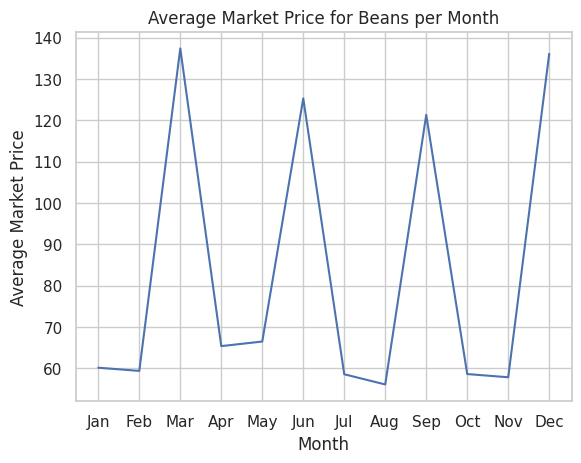

In [18]:
# Visualization to view seasonal price profile by month for Beans
monthly["month"] = monthly["date"].dt.month
beans_seasonal = monthly[monthly["commodity"] == "Beans"]
seasonal_profile = beans_seasonal.groupby("month")["price"].mean()
plt.plot(seasonal_profile.index, seasonal_profile.values)
plt.xticks(ticks=range(1, 13), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.xlabel("Month")
plt.ylabel("Average Market Price")
plt.title("Average Market Price for Beans per Month")
plt.show()


<h3>14. Year-over-year Comparison</h3>

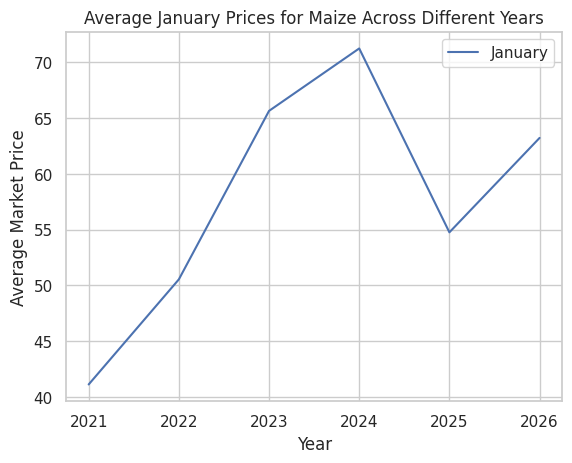

In [100]:
# Visualization to compare average January prices across different years for Maize
january_maize = monthly[(monthly["commodity"] == "Maize") & (monthly["date"].dt.month == 1) & (monthly["date"].dt.year >= 2021) & (monthly["date"].dt.year <= 2026)]
average_january_maize = january_maize.groupby(january_maize["date"].dt.year)["price"].mean()
plt.plot(average_january_maize.index, average_january_maize.values, label="January")
plt.xlabel("Year")
plt.ylabel("Average Market Price")
plt.title("Average January Prices for Maize Across Different Years")
plt.legend()
plt.show()


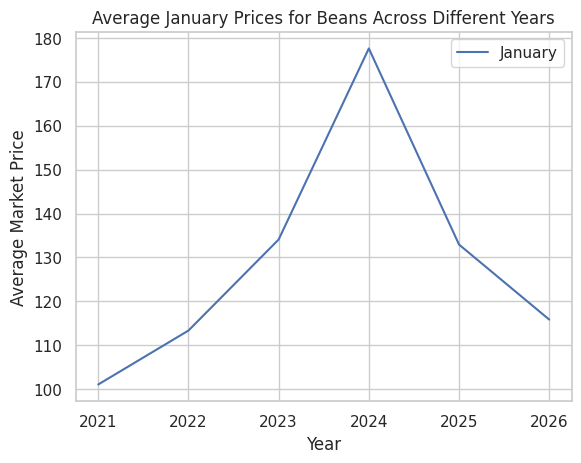

In [102]:
# Visualization to compare average January prices across different years for Beans
january_beans = monthly[(monthly["commodity"] == "Beans (dry)") & (monthly["date"].dt.month == 1) & (monthly["date"].dt.year >= 2021) & (monthly["date"].dt.year <= 2026)]
average_january_beans = january_beans.groupby(january_beans["date"].dt.year)["price"].mean()
plt.plot(average_january_beans.index, average_january_beans.values, label="January")
plt.xlabel("Year")
plt.ylabel("Average Market Price")
plt.title("Average January Prices for Beans Across Different Years")
plt.legend()
plt.show()


<h3>15. Outlier Analysis</h3>

In [133]:
# Function to identify outlier prices for a given commodity using IQR. The column for date is "date", and i want from 2014 to 2026
def get_outliers(df, commodity):
    df_filtered = df[(df["commodity"] == commodity) & (df["date"].dt.year >= 2014) & (df["date"].dt.year <= 2026)]
    Q1 = df_filtered["price"].quantile(0.25)
    Q3 = df_filtered["price"].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_filtered[(df_filtered["price"] < lower) | (df_filtered["price"] > upper)]
    return outliers

In [134]:
# Display outlier prices for Maize from 2014 to 2026 and visualize them
outliers_maize = get_outliers(df, "Maize")
outliers_maize

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
22907,2023-05-15,Rift Valley,Turkana,Ethiopia (Kakuma),3253,3.72,34.85,cereals and tubers,Maize,51,KG,aggregate,Retail,KES,100.0,0.73
23290,2023-08-15,North Eastern,Garissa,Dagahaley (Daadab),3252,0.19,40.29,cereals and tubers,Maize,51,KG,aggregate,Retail,KES,120.0,0.83
23450,2023-09-15,Rift Valley,Turkana,Ethiopia (Kakuma),3253,3.72,34.85,cereals and tubers,Maize,51,KG,aggregate,Retail,KES,100.0,0.68
23461,2023-09-15,Rift Valley,Turkana,HongKong (Kakuma),3250,3.75,34.84,cereals and tubers,Maize,51,KG,aggregate,Retail,KES,100.0,0.68
23915,2024-01-15,North Eastern,Garissa,Dagahaley (Daadab),3252,0.19,40.29,cereals and tubers,Maize,51,KG,aggregate,Retail,KES,100.0,0.63
24186,2024-03-15,Rift Valley,Turkana,HongKong (Kakuma),3250,3.75,34.84,cereals and tubers,Maize,51,KG,aggregate,Retail,KES,100.0,0.75


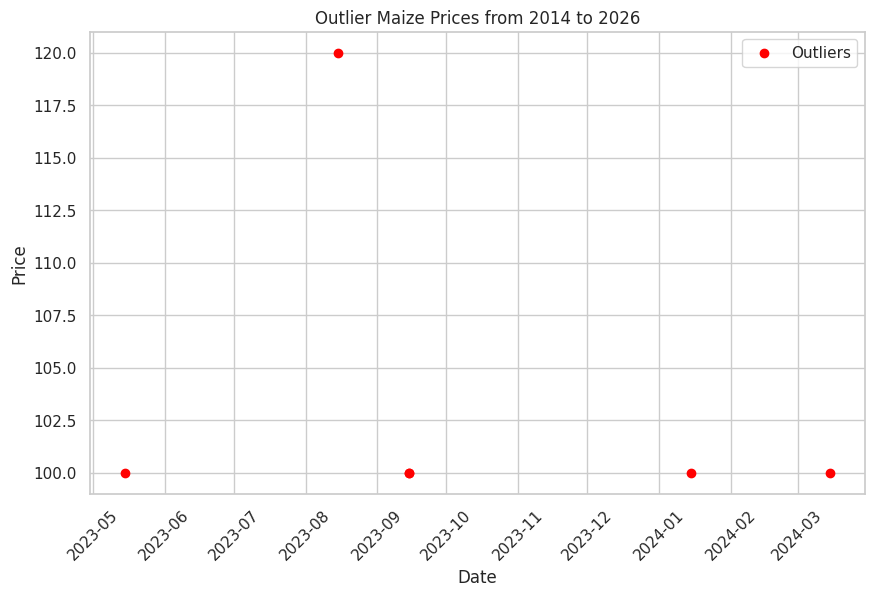

In [140]:
plt.figure(figsize=(10, 6))
plt.scatter(outliers_maize["date"], outliers_maize["price"], color='red', label='Outliers')
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("Price")
plt.title("Outlier Maize Prices from 2014 to 2026")
plt.legend()
plt.show()

In [143]:
# Display outlier prices for beans
outliers_beans = get_outliers(df, "Beans")
outliers_beans

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice


<h3>16. Market Price relationships</h3>

## Missingness overview

## Outlier detection


## Price trends by market and crop

## Seasonality check